In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import plot_importance,XGBClassifier
import joblib

In [2]:
DATA_PATH=Path("data/star_classification_CLEAN.csv")
df=pd.read_csv(DATA_PATH)
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,...,1.055431e+19,GALAXY,0.000000,9374,57749,438,-0.80827,1.07182,0.59856,0.56979
99995,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,...,8.586351e+18,GALAXY,0.404895,7626,56934,866,0.30490,1.93625,0.69244,0.34233
99996,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,...,3.112008e+18,GALAXY,0.143366,2764,54535,74,1.89919,1.06569,0.51394,0.33813
99997,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,...,7.601080e+18,GALAXY,0.455040,6751,56368,470,3.71282,1.72371,0.84132,0.44772


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   obj_ID       99999 non-null  float64
 1   alpha        99999 non-null  float64
 2   delta        99999 non-null  float64
 3   u            99999 non-null  float64
 4   g            99999 non-null  float64
 5   r            99999 non-null  float64
 6   i            99999 non-null  float64
 7   z            99999 non-null  float64
 8   run_ID       99999 non-null  int64  
 9   rerun_ID     99999 non-null  int64  
 10  cam_col      99999 non-null  int64  
 11  field_ID     99999 non-null  int64  
 12  spec_obj_ID  99999 non-null  float64
 13  class        99999 non-null  object 
 14  redshift     99999 non-null  float64
 15  plate        99999 non-null  int64  
 16  MJD          99999 non-null  int64  
 17  fiber_ID     99999 non-null  int64  
 18  u_g          99999 non-null  float64
 19  g_r 

In [4]:
id_cols=df[['obj_ID','run_ID','rerun_ID','field_ID','spec_obj_ID','fiber_ID','plate','MJD','cam_col','alpha','delta']]

In [5]:
df=df.drop(columns=id_cols,axis=1)

In [6]:
X=df[['redshift','u','g','r','i','z','u_g','g_r','r_i','i_z']]
y=df['class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

### Naive baseline

In [8]:
dummy_clf=DummyClassifier(strategy='most_frequent',random_state=42)
dummy_clf.fit(X_train,y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [9]:
y_pred = dummy_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1=(round(f1_score(y_test, y_pred, average='macro',zero_division=0),2))
conf_mat=confusion_matrix(y_test, y_pred)
print(f'Accuracy {accuracy}')
print(f'F1 score {f1}')
print(f'Confusion matrix {conf_mat}')
print(classification_report(y_test,y_pred,zero_division=0))

Accuracy 0.59445
F1 score 0.25
Confusion matrix [[11889     0     0]
 [ 3792     0     0]
 [ 4319     0     0]]
              precision    recall  f1-score   support

      GALAXY       0.59      1.00      0.75     11889
         QSO       0.00      0.00      0.00      3792
        STAR       0.00      0.00      0.00      4319

    accuracy                           0.59     20000
   macro avg       0.20      0.33      0.25     20000
weighted avg       0.35      0.59      0.44     20000



### Logistic Regression

In [10]:
log_reg_pipeline=Pipeline([('scaler',StandardScaler()),('log_reg',LogisticRegression(class_weight='balanced'))])
log_reg_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('log_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False


In [11]:
y_pred_lg=log_reg_pipeline.predict(X_test)

In [12]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_lg) * 100:.2f}%")
print(f'{classification_report(y_test,y_pred_lg)}')
print(f'{confusion_matrix(y_test,y_pred_lg)}')

Accuracy: 94.11%
              precision    recall  f1-score   support

      GALAXY       0.98      0.92      0.95     11889
         QSO       0.87      0.93      0.90      3792
        STAR       0.92      1.00      0.96      4319

    accuracy                           0.94     20000
   macro avg       0.92      0.95      0.93     20000
weighted avg       0.94      0.94      0.94     20000

[[10993   509   387]
 [  278  3510     4]
 [    0     1  4318]]


Text(50.722222222222214, 0.5, 'True')

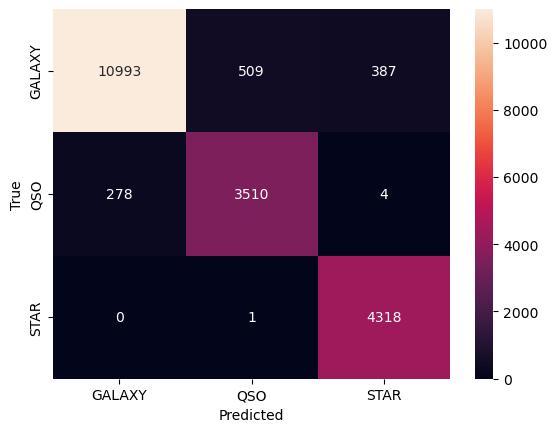

In [13]:
labels = log_reg_pipeline.classes_   # ['GALAXY','QSO','STAR']
sns.heatmap(confusion_matrix(y_test, y_pred_lg), annot=True, fmt='.0f',xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('True')

### RandomForestRegressor

In [14]:
rfg_pipe=Pipeline([('model',RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1))])

In [15]:
rfg_pipe.fit(X_train,y_train)
y_pred_rfg=rfg_pipe.predict(X_test)

In [16]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfg) * 100:.2f}%")
print(f'{classification_report(y_test,y_pred_rfg)}')
print(f'{confusion_matrix(y_test,y_pred_rfg)}')

Accuracy: 97.98%
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

[[11750   113    26]
 [  261  3531     0]
 [    3     0  4316]]


### XGBoost

In [17]:
le=LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [18]:
xgb_pipe=Pipeline([('model',XGBClassifier(n_estimators=1000,seed=42))])

In [19]:
xgb_pipe.fit(X_train,y_train_le)
y_pred_xgb=xgb_pipe.predict(X_test)

In [20]:
print(f"Accuracy: {accuracy_score(y_test_le, y_pred_xgb) * 100:.2f}%")
print(f'{classification_report(y_test_le,y_pred_xgb)}')
print(f'{confusion_matrix(y_test_le,y_pred_xgb)}')

Accuracy: 97.73%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11889
           1       0.96      0.94      0.95      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

[[11700   145    44]
 [  243  3548     1]
 [   21     0  4298]]


### SMOTE + RandomForestRegressor

In [21]:
rfg_smote = Pipeline([('smote', SMOTE(random_state=42)),('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])

In [22]:
rfg_smote.fit(X_train,y_train)
y_pred_rfg_smote=rfg_smote.predict(X_test)

In [23]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfg_smote) * 100:.2f}%")
print(f'{classification_report(y_test,y_pred_rfg_smote)}')
print(f'{confusion_matrix(y_test,y_pred_rfg_smote)}')

Accuracy: 97.91%
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.95      0.95      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000

[[11677   179    33]
 [  206  3586     0]
 [    0     0  4319]]


In [24]:
xgb_smote = Pipeline([('smote', SMOTE(random_state=42)),('model',XGBClassifier(n_estimators=1000,seed=42))])

In [25]:
xgb_smote.fit(X_train,y_train_le)
y_pred_xgb_smote=xgb_smote.predict(X_test)

In [26]:
print(f"Accuracy: {accuracy_score(y_test_le, y_pred_xgb_smote) * 100:.2f}%")
print(f'{classification_report(y_test_le,y_pred_xgb_smote)}')
print(f'{confusion_matrix(y_test_le,y_pred_xgb_smote)}')

Accuracy: 97.65%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11889
           1       0.94      0.95      0.94      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

[[11632   218    39]
 [  201  3590     1]
 [   11     0  4308]]


### RandomForestRegressor tuning

In [ ]:
rf_pipe = Pipeline([('model', RandomForestClassifier(random_state=42, n_jobs=1))])

rf_param_dist = {'model__n_estimators':[200, 300, 400, ],'model__max_depth': [ 10, 20, 30],'model__max_features':['sqrt', 'log2'],'model__min_samples_split': [2, 5, 10],
                 'model__min_samples_leaf':  [1, 2, 4],'model__class_weight': [None, 'balanced'],   }

rf_cv = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=15, scoring='f1_macro', cv=5, verbose=2,n_jobs=-1, random_state=42)
rf_cv.fit(X_train, y_train) 


Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation

In [28]:
print(rf_cv.best_score_)
rf_cv.best_params_

0.975466532837779


{'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_features': 'sqrt',
 'model__max_depth': 30,
 'model__class_weight': None}

In [35]:
rf_final_pipe=rf_cv.best_estimator_
y_pred_rf_final=rf_final_pipe.predict(X_test)

In [36]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_final) * 100:.2f}%")
print(f'{classification_report(y_test,y_pred_rf_final)}')
print(f'{confusion_matrix(y_test,y_pred_rf_final)}')

Accuracy: 98.00%
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

[[11751   113    25]
 [  259  3533     0]
 [    2     0  4317]]


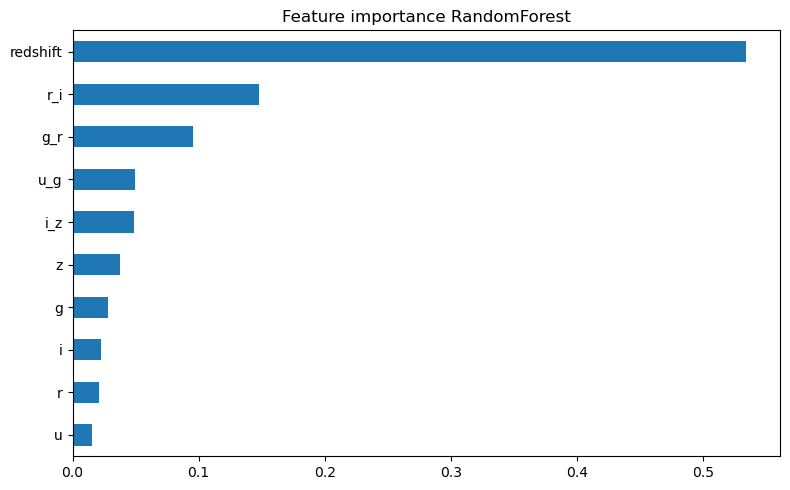

In [38]:
importances = pd.Series(rf_final_pipe.named_steps['model'].feature_importances_, index=X.columns)
importances.sort_values().plot.barh(figsize=(8,5))
plt.title('Feature importance RandomForest'); plt.tight_layout()

### XGBoost tuning

In [29]:
param_dist={'model__max_depth': [4, 5, 6, 7, 8, 9, 10,],'model__learning_rate':[ 0.01, 0.05, 0.1, 0.3], 'model__n_estimators': [300, 500, 700, 900,1100],
            'model__subsample': [0.7, 0.8, 0.9, 1.0],'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],'model__min_child_weight': [1, 3, 5, 7],}
xgb_cv=RandomizedSearchCV(estimator=xgb_pipe,param_distributions=param_dist,n_iter=40,scoring='f1_macro',cv=5,verbose=2,n_jobs=-1,random_state=42)
xgb_cv.fit(X_train,y_train_le)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validat

In [30]:
print(xgb_cv.best_score_) 

0.9737465852170593


In [31]:
xgb_cv.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 900,
 'model__min_child_weight': 1,
 'model__max_depth': 10,
 'model__learning_rate': 0.01,
 'model__colsample_bytree': 0.8}

In [32]:
xgb_final_pipe=xgb_cv.best_estimator_

In [33]:
y_pred_xgb_final=xgb_final_pipe.predict(X_test)

In [34]:
print(f"Accuracy: {accuracy_score(y_test_le, y_pred_xgb_final) * 100:.2f}%")
print(f'{classification_report(y_test_le,y_pred_xgb_final)}')
print(f'{confusion_matrix(y_test_le,y_pred_xgb_final)}')

Accuracy: 97.80%
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11889
           1       0.97      0.93      0.95      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

[[11717   124    48]
 [  248  3543     1]
 [   20     0  4299]]


<Figure size 1000x800 with 0 Axes>

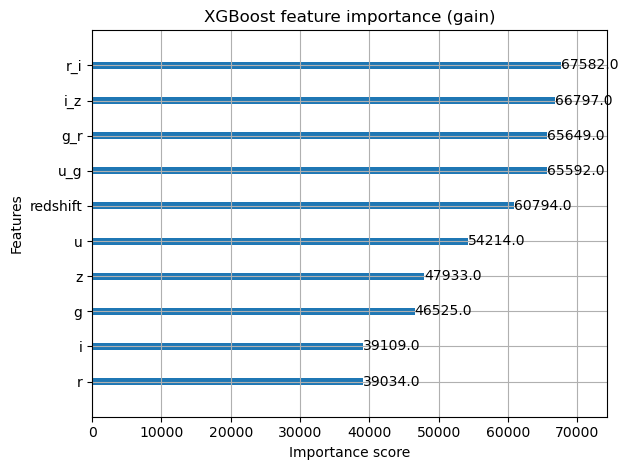

In [43]:
model = xgb_final_pipe.named_steps['model']
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=10, importance_type='weight')
plt.title('XGBoost feature importance (gain)')
plt.tight_layout(); plt.show()

<Figure size 1000x800 with 0 Axes>

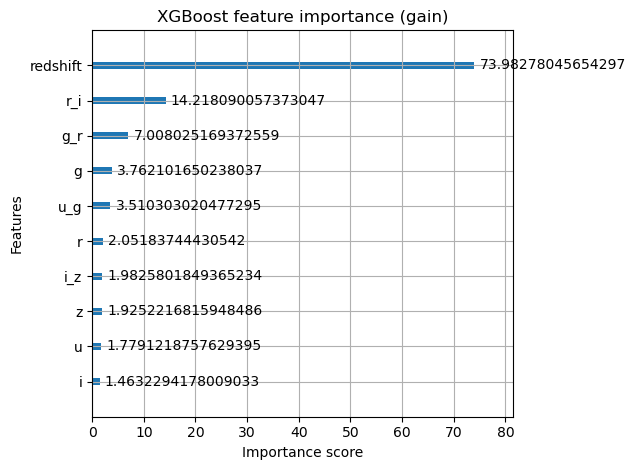

In [44]:
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=10, importance_type='gain')
plt.title('XGBoost feature importance (gain)')
plt.tight_layout(); plt.show()

In [49]:
joblib.dump(rf_final_pipe, 'models/rfg_final_model.pkl')
joblib.dump(xgb_final_pipe, 'models/xgb_final_model.pkl')

['models/xgb_final_model.pkl']